# Loop anomalies

This notebook investigates why we've seen anormalities in Loop that Lane discovered:
 - has a wider range of egv (i.e. not 40-400 like all the rest)
 - has a tail of very small iob's (the rest don't)
 - has a tail of very small tdd's (the rest don't)

In [1]:
import os, sys
from datetime import datetime, timedelta, timezone
import time
import numpy as np
import pandas as pd
from dask import dataframe as dd
import matplotlib

%matplotlib widget
import matplotlib.pyplot as plt
sys.path.append(os.path.join(os.getcwd(),'..','..'))

from src import cdf
from src import postprocessing, drawing
from studies.loop import Loop
from studies import dataset_initializer


In [2]:
data_path = os.path.join(os.getcwd(), '..','..','data', 'raw')
studies = dataset_initializer.initialize_datasets(data_path)
loop = studies['Loop']

[18:11:17] FLAIR matches multiple folders: ['FLAIRPublicDataSet.zip', 'FLAIRPublicDataSet']. Using FLAIRPublicDataSet.zip.
[18:11:17] Loop matches multiple folders: ['Loop study public dataset 2023-01-31.zip', 'Loop study public dataset 2023-01-31']. Using Loop study public dataset 2023-01-31.zip.
[18:11:17] Unmatched folders:
[18:11:17]   skip
[18:11:17]   .gitkeep
[18:11:17]   Loop study public dataset 2023-01-31
[18:11:17]   .DS_Store
[18:11:17]   FLAIRPublicDataSet
[18:11:17] Successfully matched studies with folders:
[18:11:17]   IOBP2 : /Users/jan/git/nudgebg/babelbetes/notebooks/understand-loop-dataset/../../data/raw/IOBP2 RCT Public Dataset.zip
[18:11:17]   Flair : /Users/jan/git/nudgebg/babelbetes/notebooks/understand-loop-dataset/../../data/raw/FLAIRPublicDataSet.zip
[18:11:17]   PEDAP : /Users/jan/git/nudgebg/babelbetes/notebooks/understand-loop-dataset/../../data/raw/PEDAP Public Dataset - Release 4 - 2025-04-10.zip
[18:11:17]   DCLP3 : /Users/jan/git/nudgebg/babelbetes/not

In [3]:
loop.load_data()

[18:11:18] Extracting Loop study file /Users/jan/git/nudgebg/babelbetes/notebooks/understand-loop-dataset/../../data/raw/Loop study public dataset 2023-01-31.zip
[18:11:18] Extracted path /Users/jan/git/nudgebg/babelbetes/notebooks/understand-loop-dataset/../../data/raw/Loop study public dataset 2023-01-31 already exists. Using existing folder.
[18:11:18] loop_cgm.parquet already exists. Skipping conversion.
[18:11:18] loop_basal.parquet already exists. Skipping conversion.


## CGM

In [4]:
ddf_cgm = loop._extract_cgm_as_dask()

In [5]:
r = ddf_cgm.map_partitions(lambda df: [(df.cgm<40).sum(), (df.cgm>400).sum(), df.cgm.isna().sum(), df.cgm.min(), df.cgm.max()]).compute()
r = pd.DataFrame(r.tolist(),columns=['below_40', 'above_400', 'na_count', 'min', 'max'], index=r.index)

min
39.005186    807
38.005007     26
36.004829      3
42.005544      2
40.005365      2
Name: count, dtype: int64

max
401.053653    631
400.053654     13
384.051868      7
376.050074      6
388.051864      5
Name: count, dtype: int64

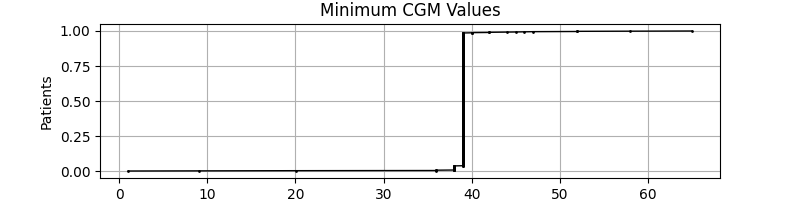

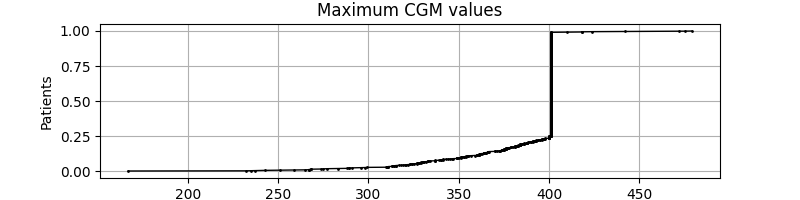

In [6]:
cdf.plot_cdf(r['min'], 'Minimum CGM Values', 'CGM', 'Patients')
display(r['min'].value_counts().sort_values(ascending=False).head(5))

cdf.plot_cdf(r['max'], 'Maximum CGM values', 'CGM', 'Patients')
display(r['max'].value_counts().sort_values(ascending=False).head(5))

In [7]:
anormalities = r.loc[(r['min']<38)|(r['max']>402)]
display(anormalities)

,below_40,above_400,na_count,min,max
57,250,142,0,36.004829,401.053653
96,107,41,0,1.000179,400.053654
149,289,8,0,38.005007,472.204933
413,79,18,0,9.001252,401.053653
421,32,383,0,39.005186,442.059017
501,8,65,0,36.004829,401.053653
504,42,61,0,39.005186,418.055438
586,114,18,0,36.004829,400.053654
632,44,85,0,39.005186,479.064386
728,3,134,0,39.005186,410.055446


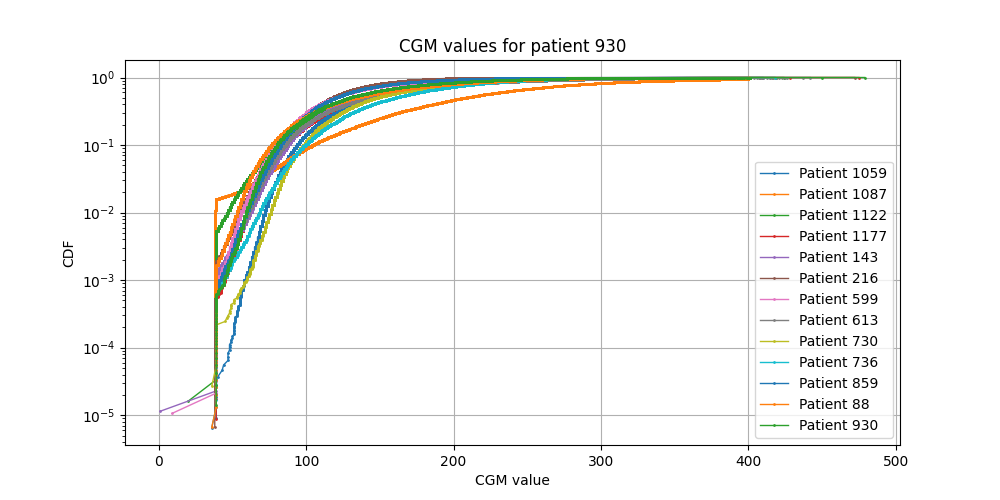

Text(0.5, 1.0, 'CGM Values Distribution for Patients with Anomalies')

In [8]:
df_subset = ddf_cgm.partitions[anormalities.index].compute()
df_subset.groupby('patient_id').size()

plt.figure(figsize=(10, 5))
ax = plt.gca()
colors = plt.cm.tab10.colors  # Use a colormap for distinct colors
for i, (patient, df) in enumerate(df_subset.groupby('patient_id')):
    color = colors[i % len(colors)]
    cdf.plot_cdf(df.cgm, f'CGM values for patient {patient}', 'CGM value', 'CDF', ax=ax, color=color, label=f'Patient {patient}')
ax.set_yscale('log')
ax.legend()
plt.show()
plt.title('CGM Values Distribution for Patients with Anomalies')

In [9]:
df_subset.loc[df_subset.cgm == df_subset.cgm.min()].sample().iloc[0]

datetime      2019-03-14 00:35:00
cgm                      1.000179
patient_id                    143
Name: 32889, dtype: object

Now, for these patients, let's draw example days with values containing their minimum values:

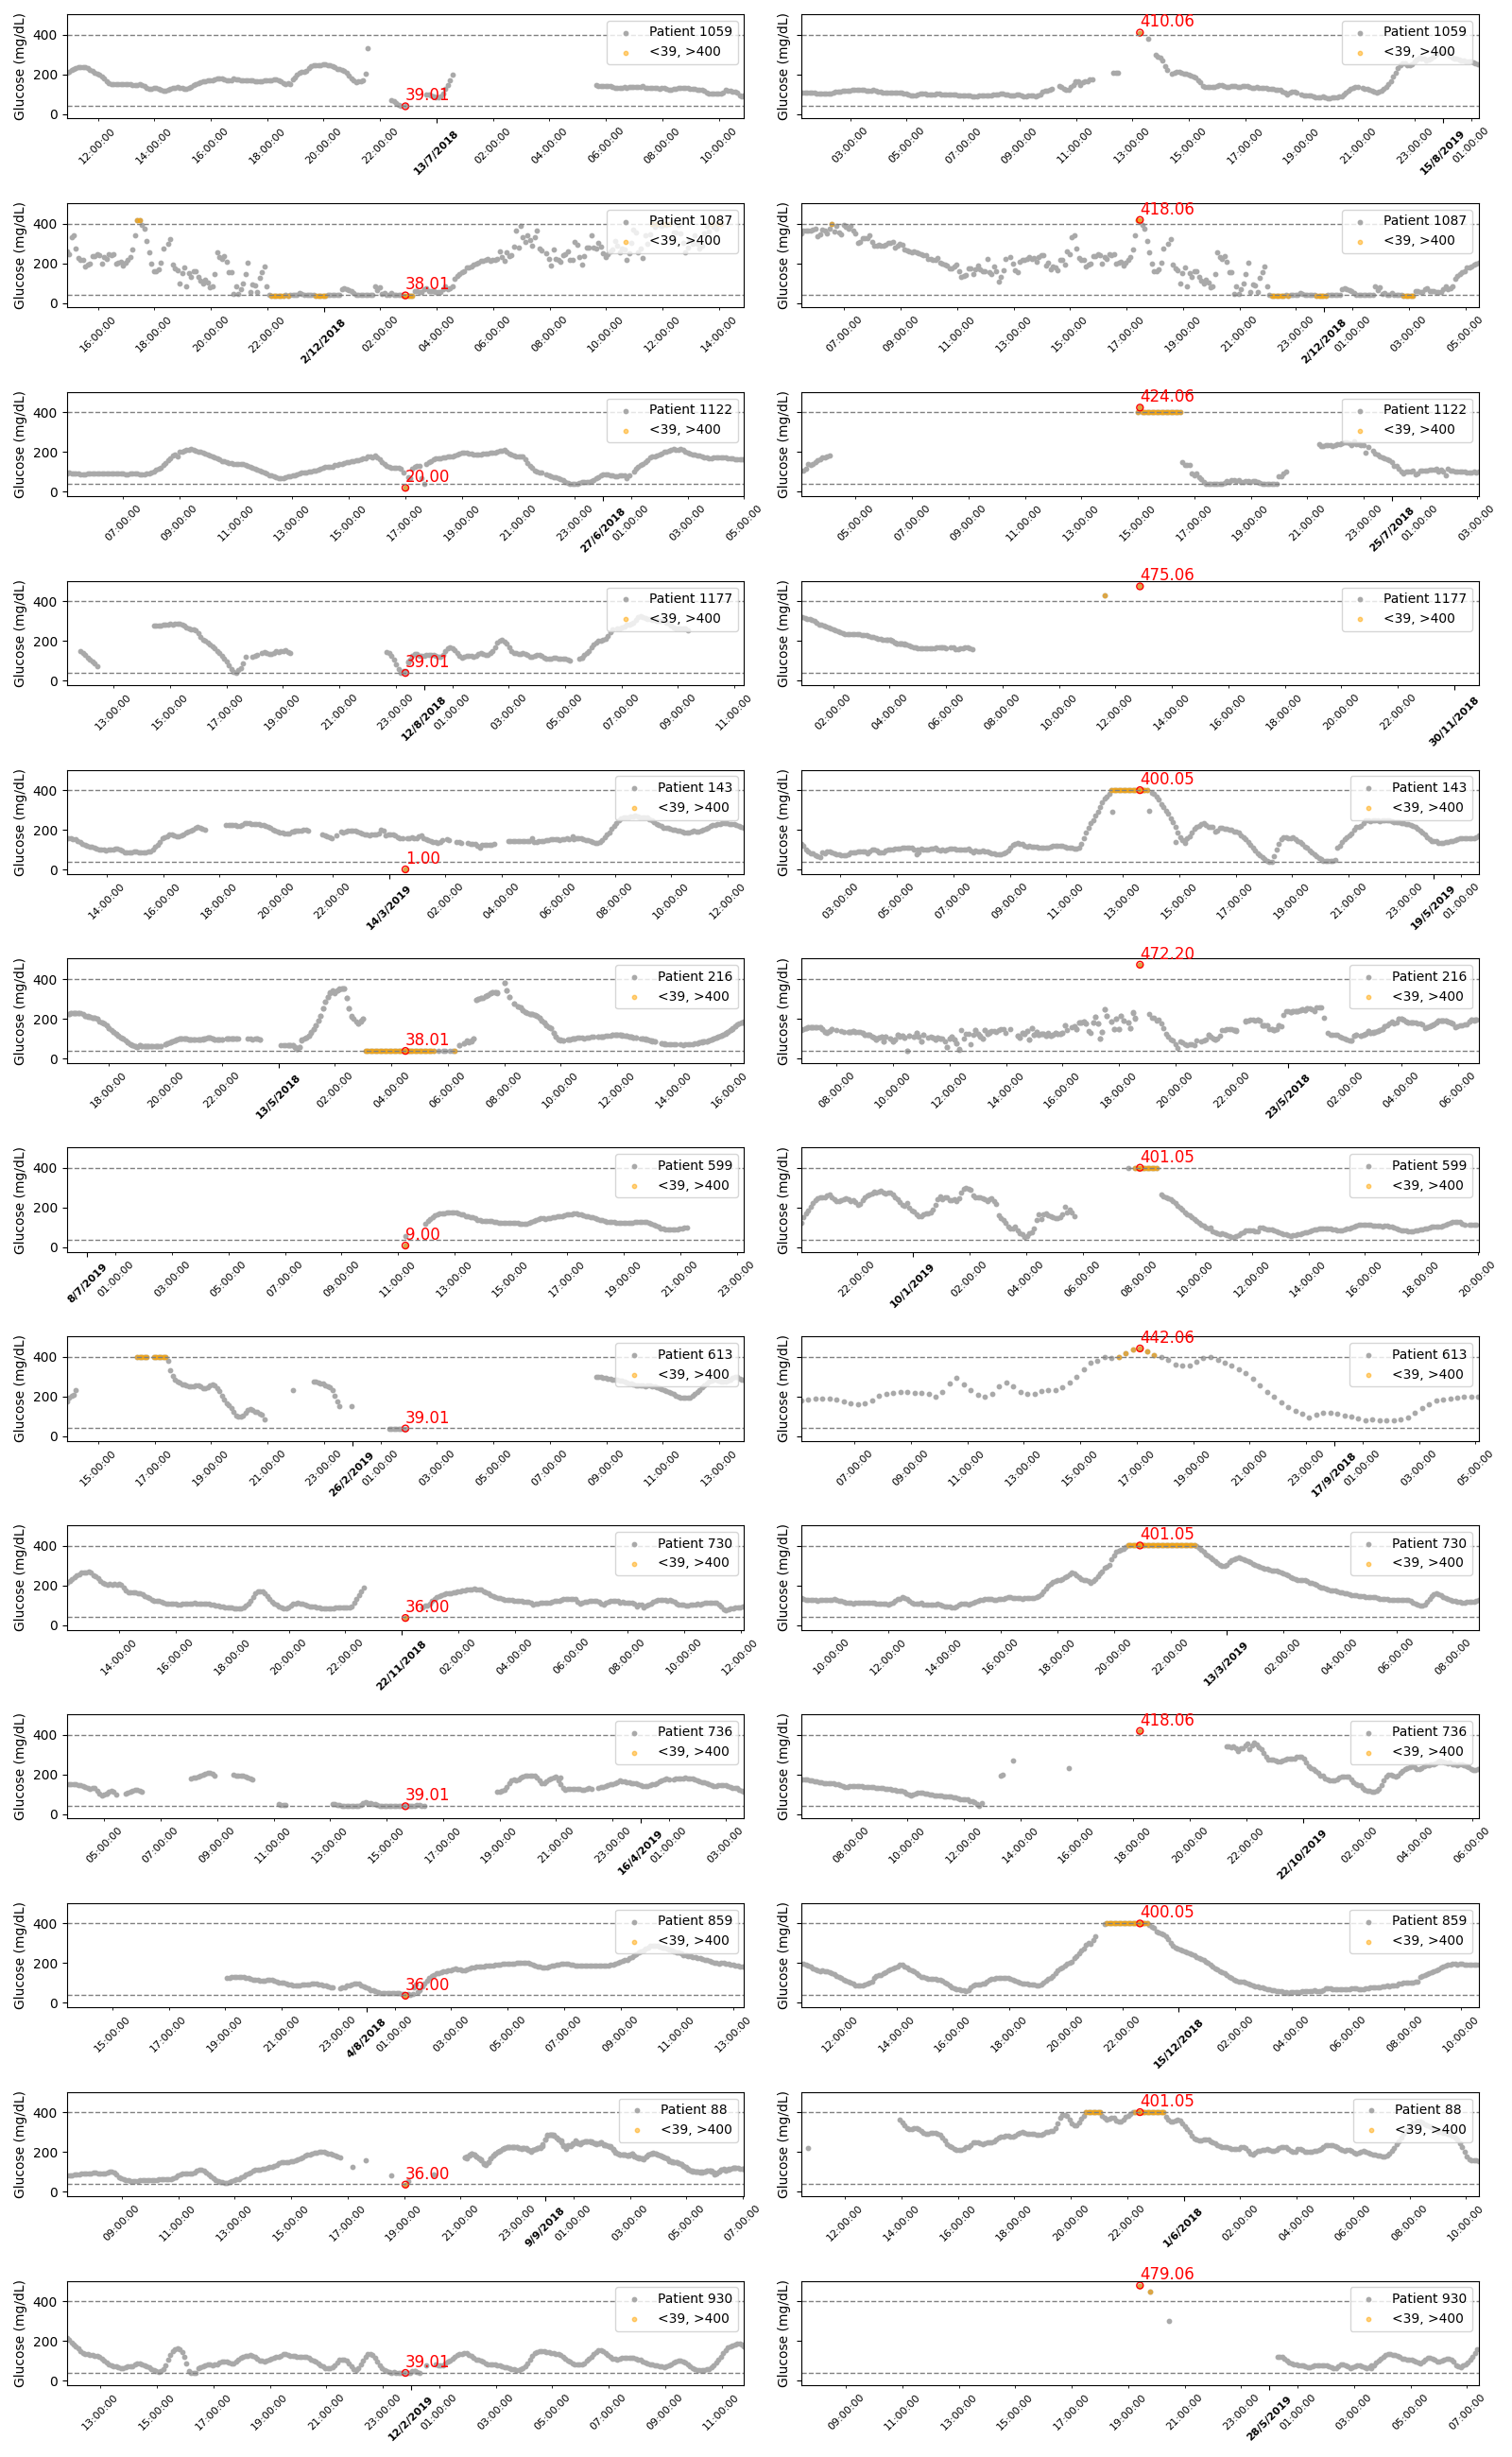

In [10]:
from src import pandas_helper
from src import drawing
grps = df_subset.groupby('patient_id')
import random 
random.seed(42)  # For reproducibility
f,AX = plt.subplots(nrows=len(grps), ncols=2, figsize=(16, 2 * len(grps)),sharey=True)
for i,(patient, df) in enumerate(grps):
    
    #get sample rows with min and max CGM values
    min_sample = df.loc[df.cgm == df.cgm.min()].sample().iloc[0]
    max_sample = df.loc[df.cgm == df.cgm.max()].sample().iloc[0]
    for j,row in enumerate([min_sample, max_sample]):
        ax = AX[i,j] 
        
        sub_frame = df.loc[df.datetime.between(row.datetime - timedelta(hours=12), row.datetime + timedelta(hours=12))]
        drawing.drawCGM(ax, sub_frame.datetime.values, sub_frame.cgm.values)
        # Get the last line drawn by drawCGM (the CGM trace)
        collections = ax.collections
        collections[0].set_label(f'Patient {patient}')
        ax.axhline(40, color='gray', linestyle='--', linewidth=1)
        ax.axhline(400, color='gray', linestyle='--', linewidth=1) 
        # Scatter points below 39 or above 401 in red
        out_range = (sub_frame.cgm < 39) | (sub_frame.cgm > 400)
        ax.scatter(sub_frame.datetime[out_range], sub_frame.cgm[out_range], color='orange', s=10, label='<39, >400', alpha=0.5)
        # Highlight the extreme value
        ax.scatter([row.datetime], [row.cgm], color='red', marker='.', s=100, facecolor='none', edgecolor='red')
        ax.text(row.datetime, row.cgm + 10, f"{row.cgm:.2f}",color='red',ha='left',va='bottom',fontsize=12)
        ax.legend(loc='upper right')
        ax.set_xlim([row.datetime - timedelta(hours=12), row.datetime + timedelta(hours=12)])
        drawing.format_time_axis(ax) 
plt.tight_layout()

In [11]:
plt.savefig(os.path.join(os.getcwd(), '..', '..', 'docs/data_sets/assets/loop_anormalities.pdf'), bbox_inches='tight')

### Observations CGM

 - Values have numerical inaccuracies (e.g. 39.005186 instead of 39)
 - Minimum and maximum values are almost always patients 39.005186 (n=807) and 401.053653 (n=631) and likely indicate out of range. 
  - For some it is 38 (n=26) and 400 (13)
- Other users show lower/higher minimum/maximum values (however only for few datapoints):  
    - Some users probably use CGMs that measure above range (e.g. patient 613)
    - Some users have values as low as 1,20, 36 which appear to occur when sensor signal is erroneous (signal stops or is very noisy): maybe these indicate sensor errors like compression, error or calibration points. 
    - They should be removed
 

## Bolus

In [4]:
df_bolus = loop._extract_bolus_event_history()
df_bolus['day'] = df_bolus.datetime.dt.date

#### CDF of daily bolus amounts

(-0.01, 1.1)

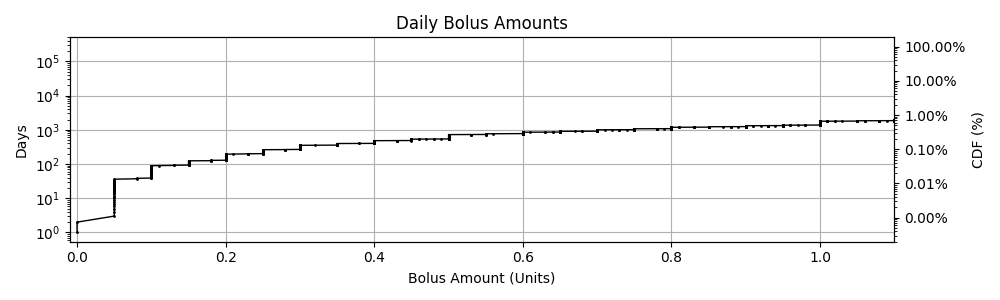

In [5]:
# Plotting the CDF of daily bolus amounts
plt.figure(figsize=(10, 3));ax = plt.gca()
cdf.plot_cdf(df_bolus.groupby(['patient_id','day']).bolus.sum(), 'Daily Bolus Amounts', 'Bolus Amount (Units)', 'Days',ax=ax, log_scaled=True,percent_right_axis=True)
plt.tight_layout()
plt.xlim(-.01,1.1)

In [6]:
#How many patients are there that have days with < 1U bolus 
n = df_bolus.groupby(['patient_id','day']).bolus.sum().reset_index().groupby('patient_id').apply(lambda x: (x.bolus < 1).any(),include_groups=False).sum()
print(f'There are {n} patients that have days with < 1U bolus')

There are 361 patients that have days with < 1U bolus


 - ~ 0.5% of days with <1U of total boluses.
 - But 361 patients have at least one day with <1 U 

Now, let's look at some examples of such days:

,patient_id,day,bolus
270110,266,2018-11-09,0.05
270111,1092,2019-04-28,0.05
270112,1183,2019-08-13,0.05
270113,982,2020-01-11,0.05
270114,569,2018-12-01,0.05
270115,1092,2019-04-23,0.05
270116,106,2019-12-14,0.05
270117,1183,2019-06-19,0.05
270118,320,2019-04-02,0.00
270119,273,2019-07-26,0.00


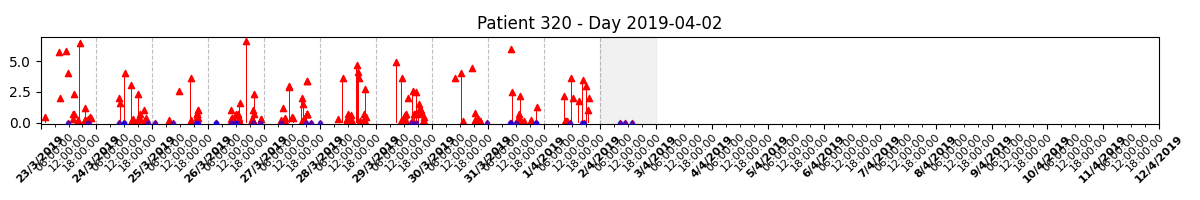

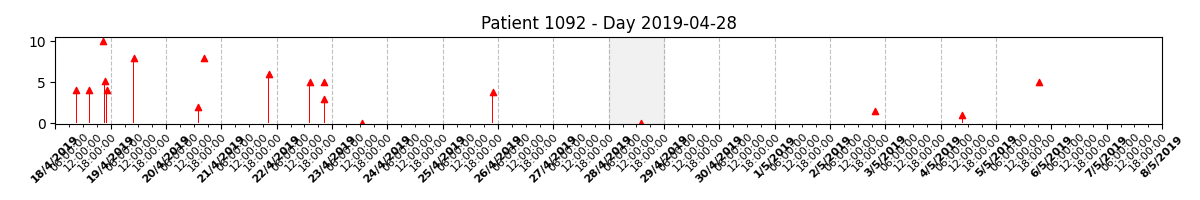

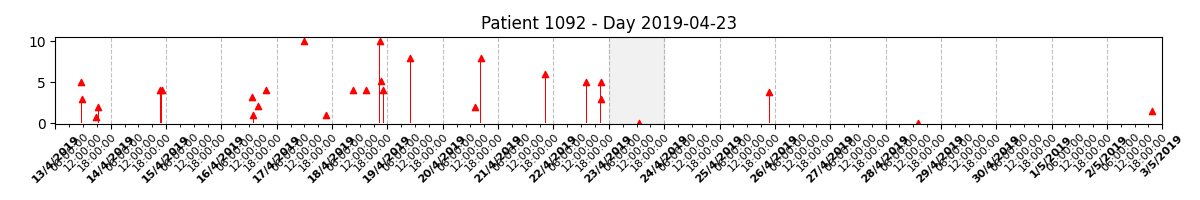

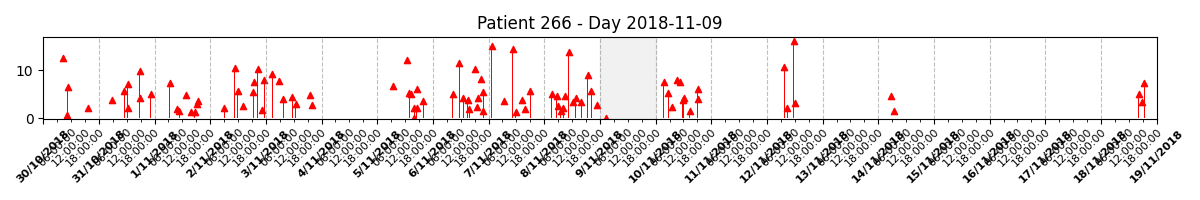

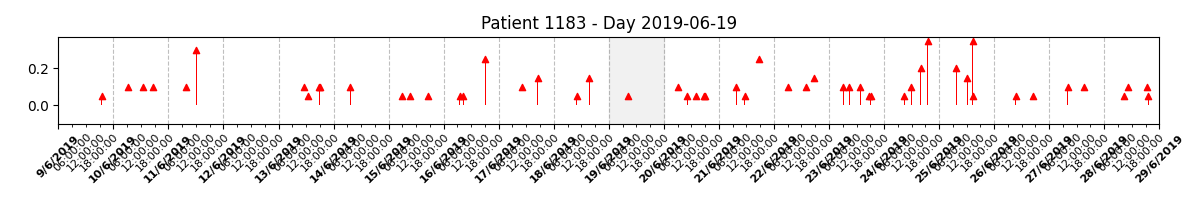

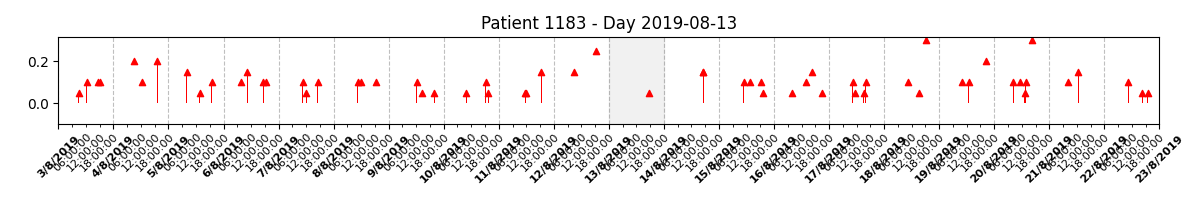

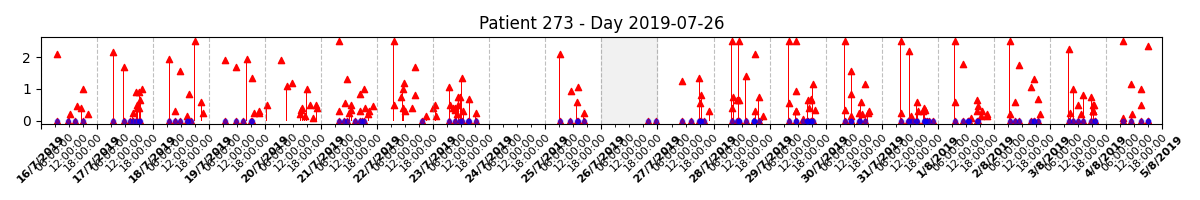

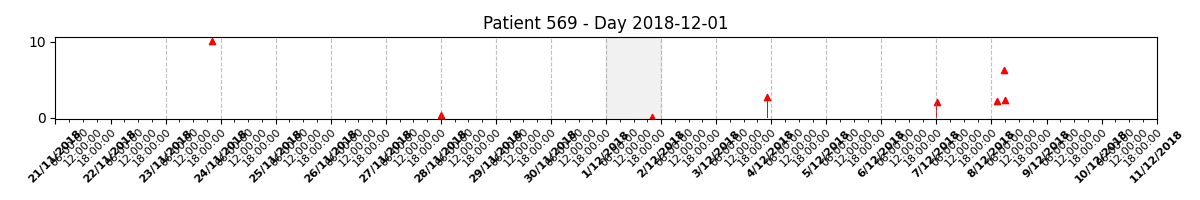

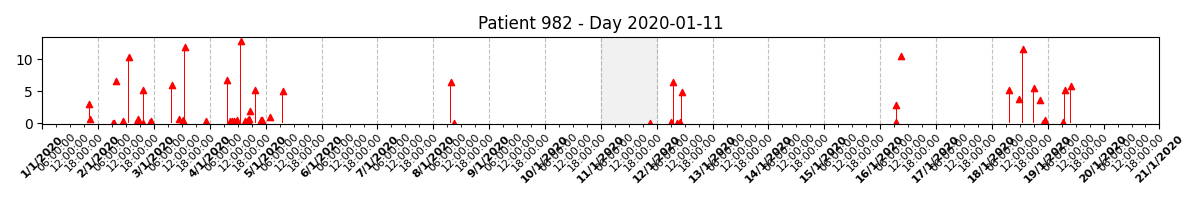

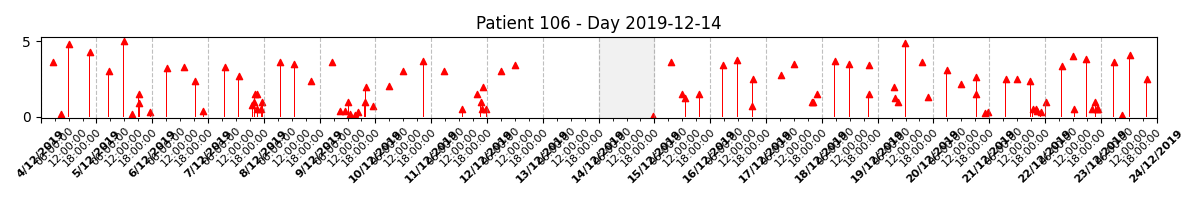

In [7]:
# Let's take a look at some days with the smallest amounts of boluses and surrounding days
daily_bolus_sum = df_bolus.groupby(['patient_id','day']).bolus.sum().sort_values(ascending=False).reset_index()
display(daily_bolus_sum.tail(10))

# Draw data for all patients in the last 10 items of the list
tail_samples = daily_bolus_sum.tail(10).sample(10, random_state=42)
for idx, sample in tail_samples.iterrows():
    #print(f"Patient {sample.patient_id}, Day {sample.day}, Bolus {sample.bolus}")
    #display(sample)
    #display(df_bolus.set_index(['patient_id','day']).loc[(sample.patient_id, sample.day)])

    day = datetime.combine(sample.day, datetime.min.time())
    patient = sample.patient_id
    date_range = (day - timedelta(days=10), day + timedelta(days=10))
    temp = df_bolus.loc[
        (df_bolus.patient_id == patient) &
        df_bolus.datetime.between(date_range[0], date_range[1])
    ]
    zero_boluses = temp.loc[temp.bolus == 0]

    plt.figure(figsize=(12, 2))

    # Highlight the background for the selected day
    ax = plt.gca()
    highlight_start = day
    highlight_end = day + timedelta(days=1)
    ax.axvspan(highlight_start, highlight_end, color='lightgray', alpha=0.3, zorder=0)
    
    #add day separator lines
    for dt in pd.date_range(temp.datetime.min().normalize(), temp.datetime.max().normalize()):
        ax.axvline(dt, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Draw the boluses
    drawing.drawBoluses(ax, temp.datetime, temp.bolus)
    ax.scatter(zero_boluses.datetime, zero_boluses.bolus, color='blue', s=10, label='Zero Bolus', alpha=0.5,zorder=4)
    drawing.format_time_axis(ax, minor_interval_hours=6)
    
    plt.ylim(-0.1, None)
    plt.xlim(date_range)
    plt.title(f'Patient {patient} - Day {sample.day}')
    plt.tight_layout()
    plt.show()

- The selected days mostly only have a single 0.05 unit bolus

By looking at the surrounding days we see that:
- Some patients show days without boluses like as if these days are missing (982,68)
- Some patients have days with boluses of zero value (66), maybe cancelled boluses
- Some patients only seem to bolus every now and then (or missing?) (569,67)
- Some patients show only micro boluses (1183)


#### Bolus statistics

In [8]:
#calculate patient bolus statistics
def p25(x):
    return np.percentile(x, 25)
def p75(x):
    return np.percentile(x, 75)

df_daily_bolus_stats = df_bolus.groupby(['patient_id','day']).agg({'bolus':['sum','count']}).bolus.groupby('patient_id').agg(['min', p25,p75, 'mean', 'max', 'sum'])
display(df_daily_bolus_stats.sample(5))


sum                                               count       \
             min     p25      p75       mean     max       sum   min  p25   
patient_id                                                                  
95          2.40  10.825  21.9125  17.067793   46.40   3789.05     1  3.0   
642         1.25   9.400  13.2250  11.487229   23.65   2653.55     3  6.0   
26          1.00  18.925  63.7000  39.539286  129.60  14945.85     1  4.0   
713         6.40  14.200  23.1250  18.825708   37.50   3991.05     2  7.0   
1074        0.55   8.025  13.7500  10.805349   22.15   2323.15     1  3.0   

                                        
             p75       mean  max   sum  
patient_id                              
95           6.0   4.378378   10   972  
642          9.0   7.532468   16  1740  
26          14.0  11.460317  144  4332  
713         12.0  17.047170   98  3614  
1074         5.0   3.948837    8   849

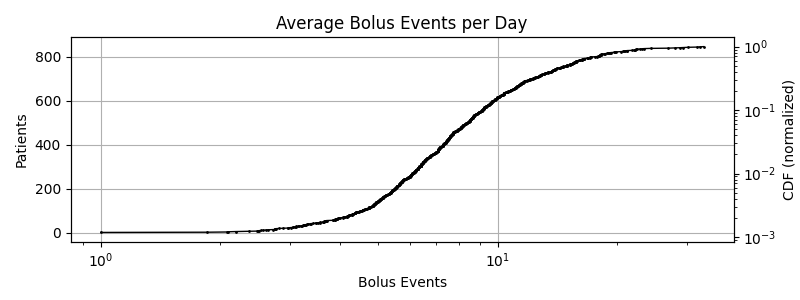

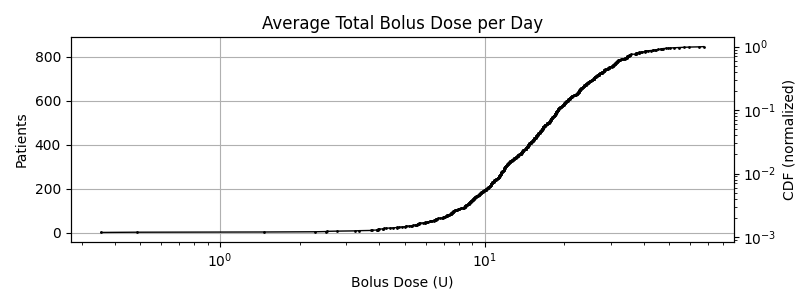

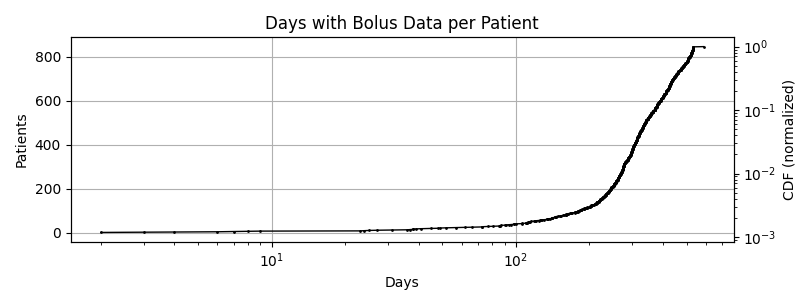

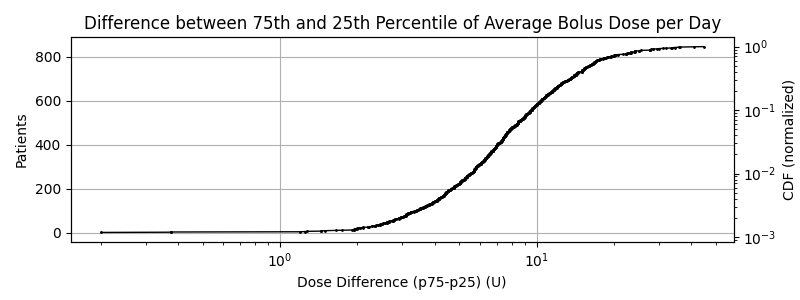

In [9]:
# some CDFs

#average events / day
plt.figure(figsize=(8, 3)); ax= plt.gca()
cdf.plot_cdf(df_daily_bolus_stats['count']['mean'], 'Average Bolus Events per Day', 'Bolus Events', 'Patients', ax=ax)
plt.tight_layout()
plt.xscale('log');plt.yscale('log')

#average total bolus dose per day
plt.figure(figsize=(8, 3)); ax= plt.gca()
cdf.plot_cdf(df_daily_bolus_stats['sum']['mean'], 'Average Total Bolus Dose per Day', 'Bolus Dose (U)', 'Patients', ax=ax)
plt.tight_layout()
plt.xscale('log'); plt.yscale('log')

#days per patient
plt.figure(figsize=(8, 3)); ax= plt.gca()
cdf.plot_cdf(df_bolus.groupby('patient_id').day.nunique(), 'Days with Bolus Data per Patient', 'Days', 'Patients', ax=ax)
plt.tight_layout()
plt.xscale('log'); plt.yscale('log')

#p75 - p25 of average bolus dose per day
plt.figure(figsize=(8, 3)); ax= plt.gca()
cdf.plot_cdf(df_daily_bolus_stats['sum']['p75'] - df_daily_bolus_stats['sum']['p25'], 
             'Difference between 75th and 25th Percentile of Average Bolus Dose per Day',
             'Dose Difference (p75-p25) (U)', 'Patients', ax=ax)
plt.tight_layout()
plt.xscale('log'); plt.yscale('log')

We know that 0.5% of days have <1 U/day

Now we learned that there are 
 - ~ n=10 patients with < 2.5 bolus events / day in average
 - ~ n=30 patients with < 5 U/day in average
 - ~ 1% patients with < 10 days of data
 - ~ 5% with >20U in p75-p25 daily dose (could indicate missing data)
 - << with almost zero avg daily boluses
 
In summary: Very few patients seem to have very bolus events, average boluses or days. 
We also know that only 0.5% of days 

/var/folders/m4/5d02b2xs0l52lbxzbk0t3vym0000gp/T/ipykernel_40069/151318330.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data.bolus.values.tolist(), vert=False, labels=labels.values, showfliers=False)


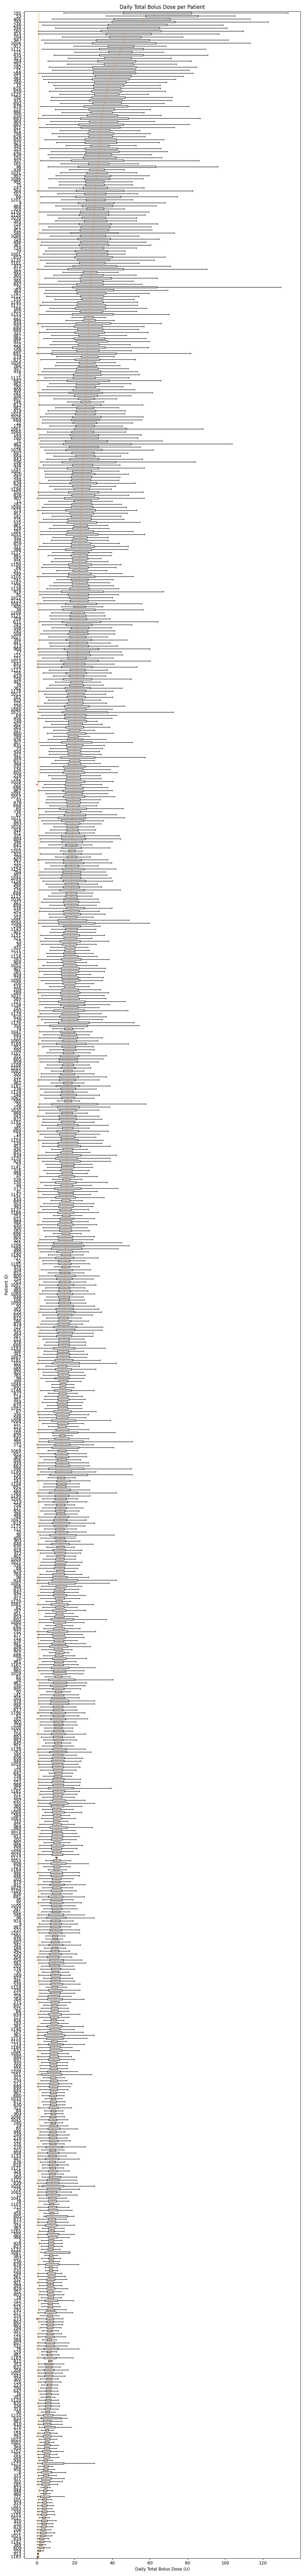

In [10]:
# Boxplot of daily total bolus dose per patient (horizontal)
import matplotlib.pyplot as plt

# Prepare data: group by patient and day, sum bolus per day
bolus_per_day = df_bolus.groupby(['patient_id', 'day']).bolus.sum().reset_index()

# Sort patient_ids by mean_doses (ascending)
mean_doses_sorted = bolus_per_day.groupby('patient_id').bolus.median().sort_values().index

# Pivot to get a list of daily doses per patient
data = bolus_per_day.groupby('patient_id').bolus.apply(lambda x: x.values).loc[mean_doses_sorted].reset_index()
labels = data.patient_id.astype(str)

plt.figure(figsize=(10, max(4, len(labels) * 0.1)))
plt.boxplot(data.bolus.values.tolist(), vert=False, labels=labels.values, showfliers=False)
plt.xlabel('Daily Total Bolus Dose (U)')
plt.ylabel('Patient ID')
plt.title('Daily Total Bolus Dose per Patient')
plt.tight_layout()

plt.axvline(1, color='orange', linestyle='--', linewidth=1, label='1U')

# Highlight patients with minimum daily bolus dose of zero
for i, vals in enumerate(data.bolus.values):
    min_val = np.min(vals)
    if min_val == 0:
        plt.scatter(min_val, i + 1, color='red', s=10, zorder=3, label='Min=0' if i == 0 else "",alpha=0.5)

# Only show one legend entry for 'Min=0'
handles, labels_ = plt.gca().get_legend_handles_labels()
if 'Min=0' in labels_:
    plt.legend(loc='lower right')
plt.show()

## TDDs

In [11]:
df_basal = loop.extract_basal_event_history()

In [12]:
from src import tdd
tdd_bolus = df_bolus.groupby(['patient_id'],observed=False).apply(lambda x: tdd.calculate_daily_bolus_dose(x), include_groups=False)

In [13]:
tdd_basal = df_basal.groupby(['patient_id'],observed=False).apply(lambda x: tdd.calculate_daily_basal_dose(x), include_groups=False)

In [32]:
#combine in tdd dataframe
tdds = pd.merge(tdd_bolus, tdd_basal, how='outer', on=['patient_id','date'], suffixes=('_bolus', '_basal')).reset_index()
tdds['sum']= tdds['bolus'] + tdds['basal']
display(tdds.sample(4))

,patient_id,date,bolus,basal,sum
44183,1148,2018-12-15,13.55,15.401393,28.951393
60638,1201,2019-02-28,39.15,20.640495,59.790495
179703,571,2019-01-17,12.45,10.790530,23.240530
234246,778,2020-02-05,17.40,34.368741,51.768741


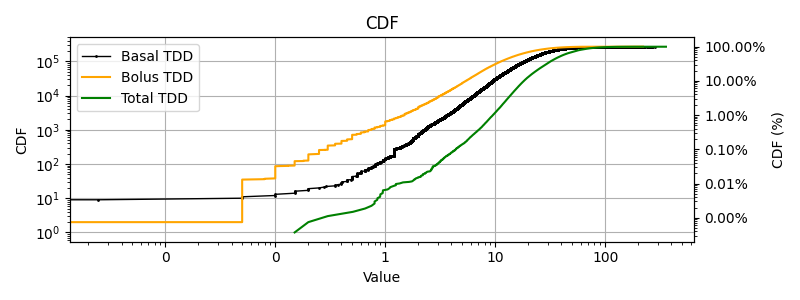

In [ ]:
#CDF of TDDs
from matplotlib.ticker import FuncFormatter
#plot tdd cdfs
plt.figure(figsize=(8, 3)); ax= plt.gca()
cdf.plot_cdf(tdds.basal.dropna(), ax=ax,log_scaled=True,label='Basal TDD',percent_right_axis=True)

data_sorted, cdfs = cdf.get_cdf(tdds.bolus.dropna(),normalize=False)
ax.plot(data_sorted, cdfs, color='orange', label='Bolus TDD')

data_sorted, cdfs = cdf.get_cdf(tdds['sum'].dropna(),normalize=False)
ax.plot(data_sorted, cdfs, color='green', label='Total TDD')
ax.legend()

plt.xscale('log')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}'))
plt.tight_layout()

 - 0.01% with TDD < 1U
 - 0.05% with TDD < 3U

In [36]:
#stats
def mingezero(x):
    """Calculate the minimum TDD greater than zero."""
    return x.loc[x > 0].min()

def count_zeros(x):
    """Count the number of zeros."""
    return (x == 0).sum()

def count_nans(x):
    """Count the number of NaNs."""
    return x.isna().sum()

tdds.agg({
    'basal': ['min', mingezero, 'mean', 'max', count_zeros, count_nans],
    'bolus': ['min', mingezero, 'mean', 'max', count_zeros, count_nans],
    'sum':   ['min', mingezero, 'mean', 'max', count_zeros, count_nans]
})

,basal,bolus,sum
min,0.000000,0.000000,0.150000
mingezero,0.002444,0.050000,0.150000
mean,25.743872,17.284608,42.780595
max,332.998731,221.150000,357.209597
count_zeros,18.000000,2.000000,0.000000
count_nans,23297.000000,25007.000000,27763.000000


We see some 1700 days with NaN basal TDD
The way we calculate TDDs, we set basal tdd to nan when there are insufficient support points from the pump. 
For boluses we don't do this. 
This is because we can't really tell if pump data is missing or not but expect at least one basal sample per day.

Lane reported minimum TDD in Loop of 0.0014 Units which is not what we see. 

#### Example days with low TDDs and surrounding data

In [37]:
df_basal

,patient_id,datetime,basal_rate
0,3,2018-09-08 16:16:47,0.410
1,3,2018-09-08 17:30:00,0.467
2,3,2018-09-08 19:00:00,0.550
3,3,2018-09-08 21:00:00,0.500
4,3,2018-09-08 23:00:00,0.333
...,...,...,...
20301,1212,2018-11-28 18:01:22,3.399
20302,1212,2018-11-28 18:02:15,3.790
20303,1212,2018-11-28 18:06:13,4.040
20304,1212,2018-11-28 18:31:28,0.000


/var/folders/m4/5d02b2xs0l52lbxzbk0t3vym0000gp/T/ipykernel_40069/753606761.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(14, 3))


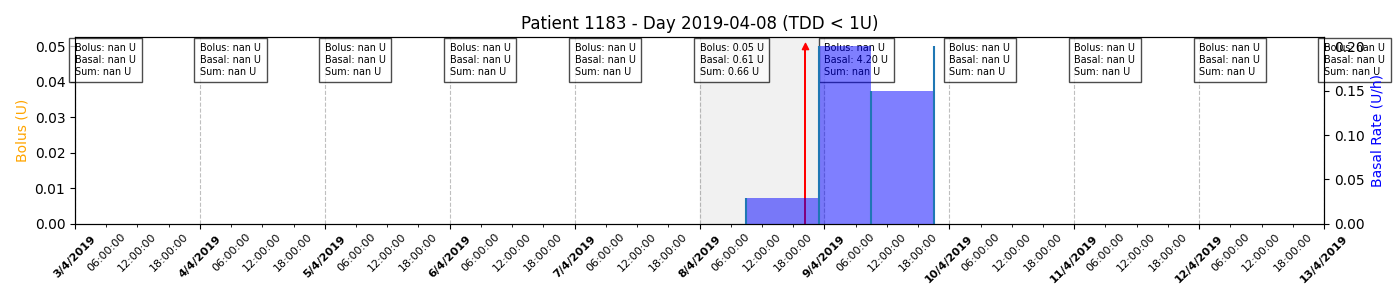

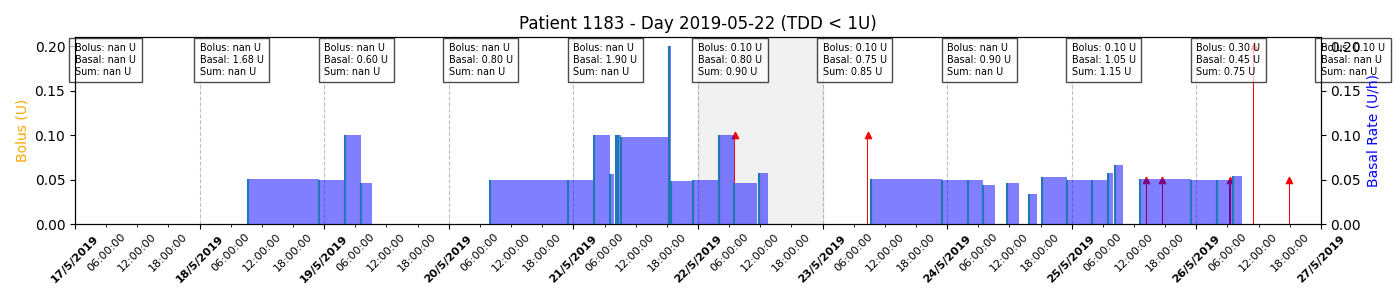

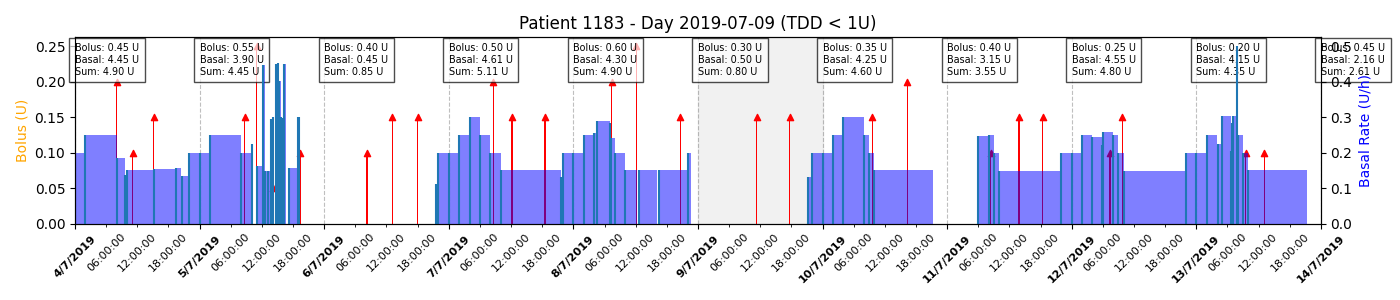

In [38]:
# Select random TDDs with sum < 1 and plot bolus and basal data around those days
from src import drawing

# Filter for days with sum < 1
low_tdd_days = tdds.loc[tdds['sum'] < 1].sample(3, random_state=42)

for idx, row in low_tdd_days.iterrows():
    patient = row['patient_id']
    day = row['date']
    day_dt = pd.to_datetime(day)
    date_range = (day_dt - timedelta(days=5), day_dt + timedelta(days=5))
    
    # Bolus data for this patient and range
    temp_bolus = df_bolus.loc[
        (df_bolus.patient_id == patient) &
        (df_bolus.datetime.between(date_range[0], date_range[1]))
    ]
    # Basal data for this patient and range
    temp_basal = df_basal.loc[
        (df_basal.patient_id == patient) &
        (df_basal.datetime.between(date_range[0], date_range[1]))
    ]
    
    plt.figure(figsize=(14, 3))
    ax = plt.gca()
    # Highlight the background for the selected day
    highlight_start = day_dt
    highlight_end = day_dt + timedelta(days=1)
    ax.axvspan(highlight_start, highlight_end, color='lightgray', alpha=0.3, zorder=0)
    
    # Add day separator lines
    for dt in pd.date_range(date_range[0].normalize(), date_range[1].normalize()):
        ax.axvline(dt, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Draw boluses
    drawing.drawBoluses(ax, temp_bolus.datetime, temp_bolus.bolus)
    ax.set_ylabel('Bolus (U)', color='orange')
    
    # Draw basal rates
    if not temp_basal.empty:
        axtwin = ax.twinx()
        drawing.drawBasal(axtwin, temp_basal.datetime.values, temp_basal.basal_rate.values)
        axtwin.set_ylabel('Basal Rate (U/h)', color='blue')
    
    drawing.format_time_axis(ax, minor_interval_hours=6)

    # Add text annotation with bolus, basal, and sum TDD for the selected day
    for dt in pd.date_range(date_range[0], date_range[1]):
        tdd_row = tdds[(tdds['patient_id'] == patient) & (tdds['date'] == dt.date())]
        if not tdd_row.empty:
            ax.text(
                dt.normalize(),
                ax.get_ylim()[1] * 0.8, 
                f"Bolus: {tdd_row['bolus'].values[0]:.2f} U\nBasal: {tdd_row['basal'].values[0]:.2f} U\nSum: {tdd_row['sum'].values[0]:.2f} U", color='black', fontsize='x-small', bbox=dict(facecolor='white', alpha=0.7))
    plt.xlim(date_range)
    plt.title(f'Patient {patient} - Day {day} (TDD < 1U)')
    plt.tight_layout()
    plt.show()